In [50]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [109]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import datetime as dt

In [65]:
# results_path = pathlib.Path('/Users/alexnaokiasatokobayashi/Documents/data/Gals/results')
# results_path = pathlib.Path('/Users/alexnaokiasatokobayashi/Documents/data/Kerzers/CHYN-Kerzers01/low-cost_sensor_results_optimized/test01')
results_path = pathlib.Path('/Users/alexnaokiasatokobayashi/Documents/data/Kerzers/CHYN-Kerzers01/low-cost_sensor_results_optimized/plot4')
files = list(results_path.glob('*bestPareto.nc'))
nc_list = []
for file in files:
    # if not file.name.startswith('test8k'):
    #     continue
    # else:
    #     pass
    print(file.name)
    nc_list.append(file)

test01_2025-10-07_bestPareto.nc
test01_2025-09-25_bestPareto.nc
test01_2025-10-03_bestPareto.nc
test01_2025-09-26_bestPareto.nc
test01_2025-10-04_bestPareto.nc
test01_2025-09-22_bestPareto.nc
test01_2025-09-28_bestPareto.nc
test01_2025-09-29_bestPareto.nc
test01_2025-09-23_bestPareto.nc
test01_2025-10-01_bestPareto.nc
test01_2025-10-05_bestPareto.nc
test01_2025-09-30_bestPareto.nc
test01_2025-09-27_bestPareto.nc
test01_2025-10-02_bestPareto.nc
test01_2025-09-24_bestPareto.nc
test01_2025-10-06_bestPareto.nc


In [66]:
nc_list

[PosixPath('/Users/alexnaokiasatokobayashi/Documents/data/Kerzers/CHYN-Kerzers01/low-cost_sensor_results_optimized/plot4/test01_2025-10-07_bestPareto.nc'),
 PosixPath('/Users/alexnaokiasatokobayashi/Documents/data/Kerzers/CHYN-Kerzers01/low-cost_sensor_results_optimized/plot4/test01_2025-09-25_bestPareto.nc'),
 PosixPath('/Users/alexnaokiasatokobayashi/Documents/data/Kerzers/CHYN-Kerzers01/low-cost_sensor_results_optimized/plot4/test01_2025-10-03_bestPareto.nc'),
 PosixPath('/Users/alexnaokiasatokobayashi/Documents/data/Kerzers/CHYN-Kerzers01/low-cost_sensor_results_optimized/plot4/test01_2025-09-26_bestPareto.nc'),
 PosixPath('/Users/alexnaokiasatokobayashi/Documents/data/Kerzers/CHYN-Kerzers01/low-cost_sensor_results_optimized/plot4/test01_2025-10-04_bestPareto.nc'),
 PosixPath('/Users/alexnaokiasatokobayashi/Documents/data/Kerzers/CHYN-Kerzers01/low-cost_sensor_results_optimized/plot4/test01_2025-09-22_bestPareto.nc'),
 PosixPath('/Users/alexnaokiasatokobayashi/Documents/data/Kerzer

In [67]:
ds = None
for file in files:
    print(file.name)
    if ds is None:
        ds = xr.open_dataset(file)
        print(ds.time.min())
    else:
        ds2 = xr.open_dataset(file)
        ds = xr.concat([ds, ds2], dim='time')
        print(ds2.time.min())
    print()
    print()
    # print(ds)


test01_2025-10-07_bestPareto.nc
<xarray.DataArray 'time' ()> Size: 8B
array('2025-10-07T00:23:50.000000000', dtype='datetime64[ns]')


test01_2025-09-25_bestPareto.nc
<xarray.DataArray 'time' ()> Size: 8B
array('2025-09-25T00:01:37.000000000', dtype='datetime64[ns]')


test01_2025-10-03_bestPareto.nc
<xarray.DataArray 'time' ()> Size: 8B
array('2025-10-03T00:24:50.000000000', dtype='datetime64[ns]')


test01_2025-09-26_bestPareto.nc
<xarray.DataArray 'time' ()> Size: 8B
array('2025-09-26T00:05:09.000000000', dtype='datetime64[ns]')


test01_2025-10-04_bestPareto.nc
<xarray.DataArray 'time' ()> Size: 8B
array('2025-10-04T00:02:39.000000000', dtype='datetime64[ns]')


test01_2025-09-22_bestPareto.nc
<xarray.DataArray 'time' ()> Size: 8B
array('2025-09-22T00:13:38.000000000', dtype='datetime64[ns]')


test01_2025-09-28_bestPareto.nc
<xarray.DataArray 'time' ()> Size: 8B
array('2025-09-28T00:17:24.000000000', dtype='datetime64[ns]')


test01_2025-09-29_bestPareto.nc
<xarray.DataArray 'time

In [68]:
ds

<xarray.Dataset> Size: 58MB
Dimensions:        (time: 1810, MC: 8000)
Coordinates:
  * MC             (MC) int64 64kB 0 1 2 3 4 5 ... 7994 7995 7996 7997 7998 7999
  * time           (time) datetime64[ns] 14kB 2025-10-07T00:23:50 ... 2025-10...
Data variables:
    dcdt(HM)       (time, MC) float32 58MB 0.528 0.5248 0.5328 ... 0.5556 0.5533
    best_deadband  (time) int64 14kB 20 40 30 20 40 10 30 ... 10 20 50 20 50 30
    best_cutoff    (time) int64 14kB 100 120 90 80 110 80 ... 100 110 80 110 100

In [76]:
ds.time.values

array(['2025-10-07T00:23:50.000000000', '2025-10-07T00:29:05.000000000',
       '2025-10-07T00:34:20.000000000', ...,
       '2025-10-06T23:21:52.000000000', '2025-10-06T23:47:36.000000000',
       '2025-10-06T23:52:51.000000000'], dtype='datetime64[ns]')

In [78]:
ds2 = ds.sortby('time')

In [87]:
ds2.where(ds2['dcdt(HM)']>0)

<xarray.Dataset> Size: 290MB
Dimensions:        (time: 1810, MC: 8000)
Coordinates:
  * MC             (MC) int64 64kB 0 1 2 3 4 5 ... 7994 7995 7996 7997 7998 7999
  * time           (time) datetime64[ns] 14kB 2025-09-22T00:13:38 ... 2025-10...
Data variables:
    dcdt(HM)       (time, MC) float32 58MB 0.7148 0.7157 0.7218 ... 0.767 0.7509
    best_deadband  (time, MC) float64 116MB 10.0 10.0 10.0 ... 30.0 30.0 30.0
    best_cutoff    (time, MC) float64 116MB 100.0 100.0 100.0 ... 110.0 110.0

In [111]:
ds2.time

<xarray.DataArray 'time' (time: 1810)> Size: 14kB
array(['2025-09-22T00:13:38.000000000', '2025-09-22T00:18:53.000000000',
       '2025-09-22T00:24:07.000000000', ..., '2025-10-07T12:02:25.000000000',
       '2025-10-07T12:28:08.000000000', '2025-10-07T12:33:23.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 14kB 2025-09-22T00:13:38 ... 2025-10-07T12...

[0.01890636 0.01171169 0.02229923 ... 0.00983831 0.01317972 0.01846147]
DatetimeIndex(['2025-09-25', '2025-09-26', '2025-09-27', '2025-09-28',
               '2025-09-29', '2025-09-30', '2025-10-01', '2025-10-02',
               '2025-10-03', '2025-10-04', '2025-10-05'],
              dtype='datetime64[ns]', freq=None)


/Users/alexnaokiasatokobayashi/.local/share/mamba/envs/FCS/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/var/folders/92/kgbg9kx56kzdvzzmyn2vvmym0000gn/T/ipykernel_56881/2405700380.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

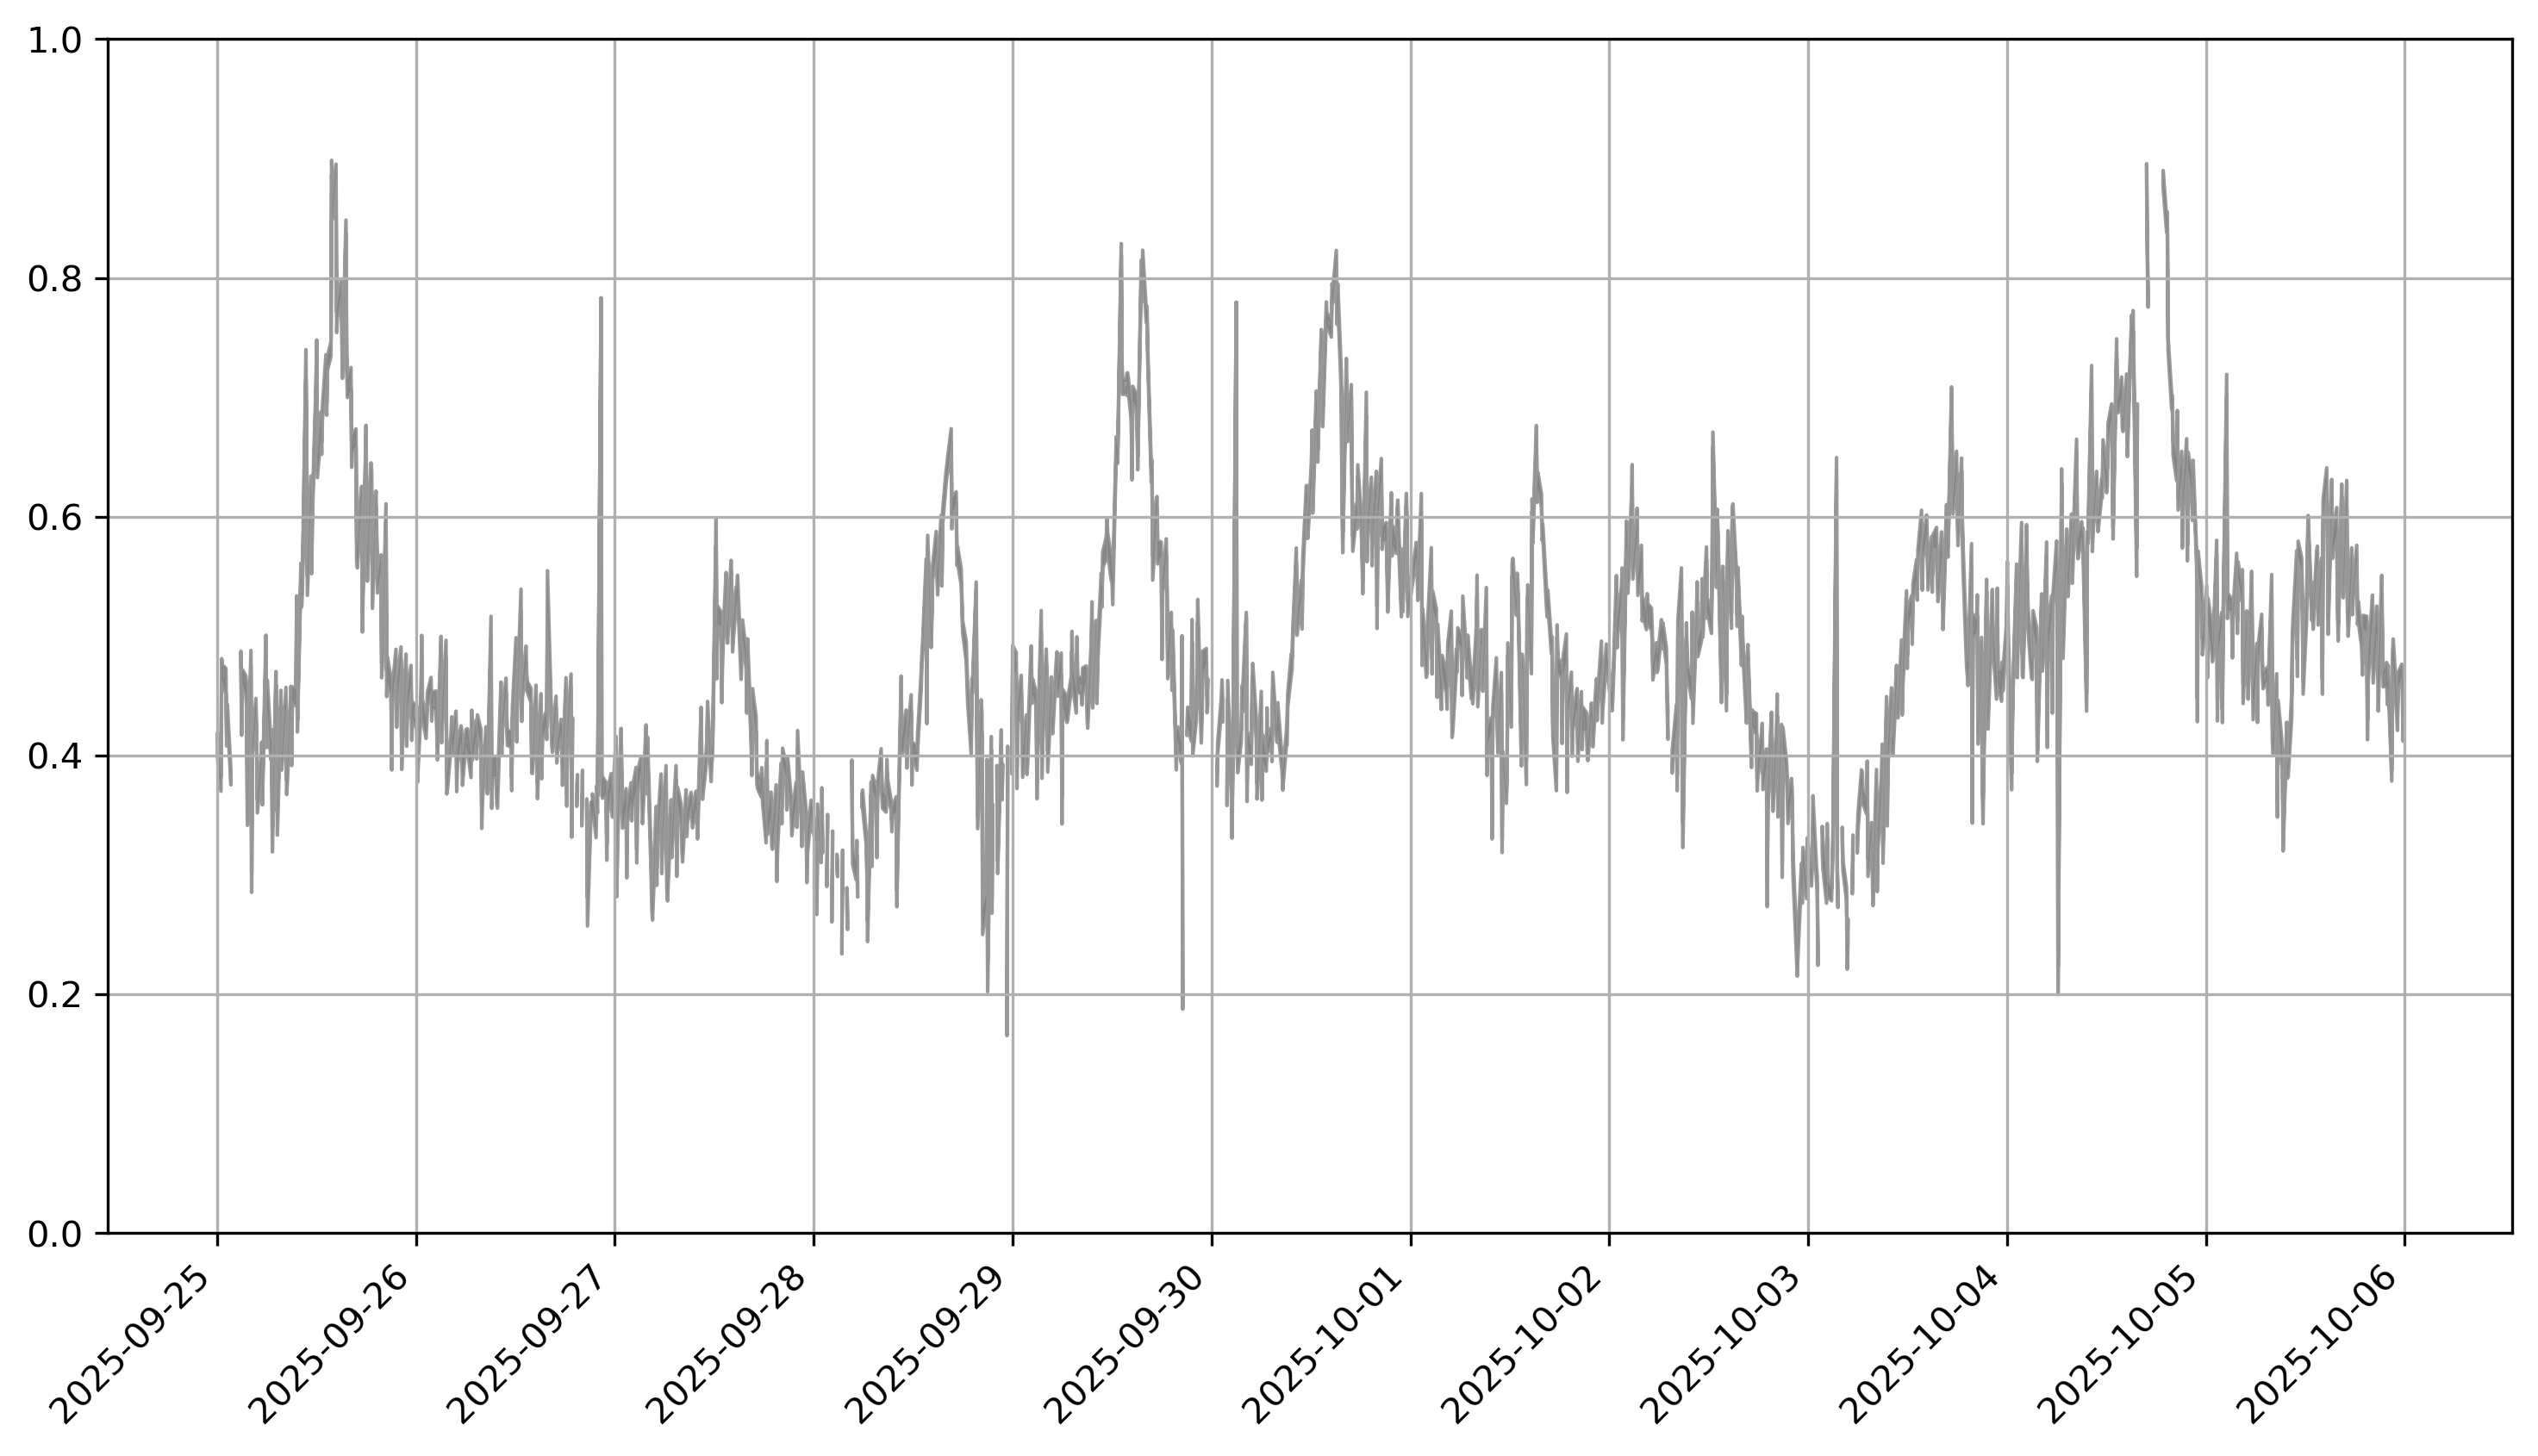

In [114]:
fig, ax = plt.subplots(figsize=(12,6), dpi=300)

ds2 = ds2.where((ds2['dcdt(HM)']>0.1)&(ds2['dcdt(HM)']<0.9))

# filter dates: set start and end date here
start_date = pd.to_datetime('2025-09-25')
end_date = pd.to_datetime('2025-10-06')
ds2 = ds2.sel(time=slice(start_date, end_date))

dcdt_median = ds2['dcdt(HM)'].median(dim='MC').values
dcdt_q16 = ds2['dcdt(HM)'].quantile(0.16, dim='MC').values
dcdt_q84 = ds2['dcdt(HM)'].quantile(0.84, dim='MC').values

print(dcdt_q84-dcdt_q16)
time = ds2['time'].values

days = pd.to_datetime(time).normalize().unique()
print(days)

# print(ds['dcdt(HM)'].median(dim='MC').values)
# ax.scatter(time, dcdt_median, label='median', s=1)
ax.fill_between(time, dcdt_q16, dcdt_q84, color='gray', alpha=0.8, label='16-84th percentile')
ax.set_ylim(0, 1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.grid()

import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.DayLocator())          # daily ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # or '%m-%d', etc.
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')


In [71]:
ds['sgf']

KeyError: "No variable named 'sgf'. Variables on the dataset include ['dcdt(HM)', 'best_deadband', 'best_cutoff', 'MC', 'time']"

KeyError: "No variable named 'sgf'. Variables on the dataset include ['dcdt(HM)', 'best_deadband', 'best_cutoff', 'MC', 'time']"

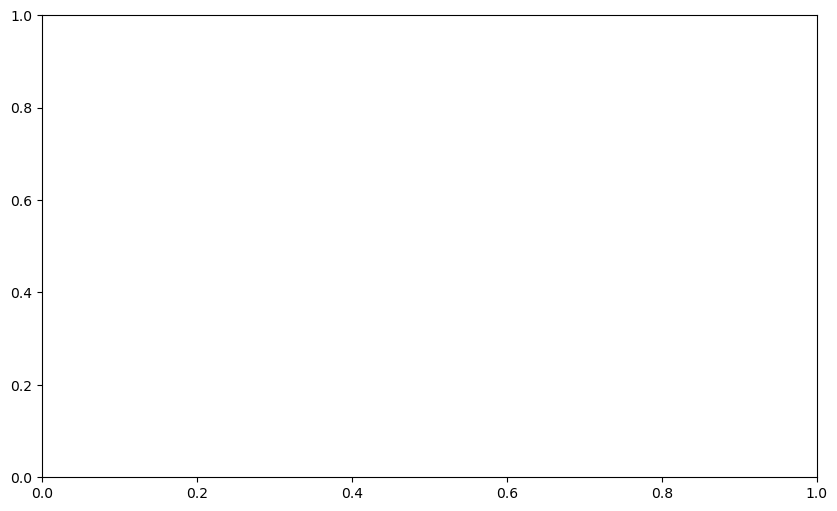

In [72]:
fig, ax = plt.subplots(figsize=(10, 6))

dcdt_median = ds['sgf'].median(dim='MC').values
time = ds['time'].values

# print(ds['dcdt(HM)'].median(dim='MC').values)
ax.scatter(time, dcdt_median, label='median', s=1)
ax.set_ylabel('Soil Gas Flux ($\mu mol\ m^{-2}\ s^{-1}$)')
ax.set_xlabel('Time')
# ax.set_title('Soil Gas Flux over Time')
# ax.
ax.grid(True)

In [73]:
12*1e-6*24*60*60*1e4/1e3


10.368

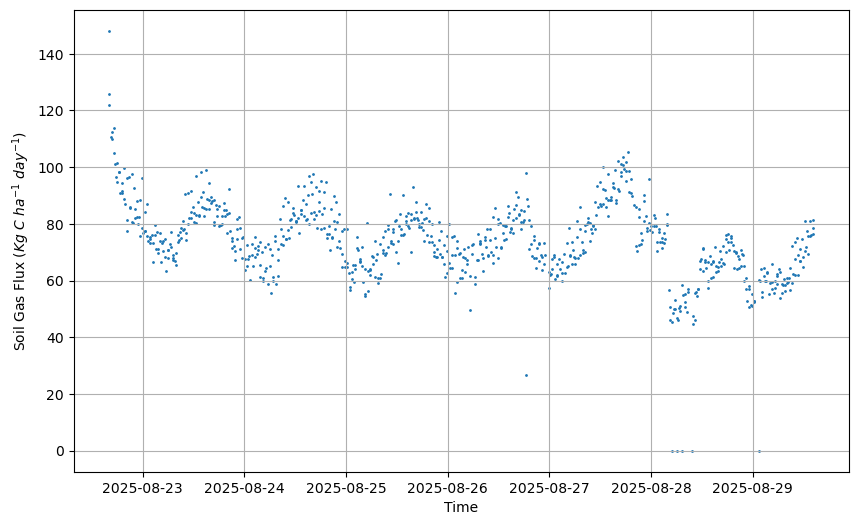

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

dcdt_median = ds['sgf'].median(dim='MC').values*12*1e-6*24*60*60*1e4/1e3
time = ds['time'].values

# print(ds['dcdt(HM)'].median(dim='MC').values)
ax.scatter(time, dcdt_median, label='median', s=1)
ax.set_ylabel('Soil Gas Flux ($Kg\ C\ ha^{-1}\ day^{-1}$)')
ax.set_xlabel('Time')
# ax.set_title('Soil Gas Flux over Time')
# ax.
ax.grid(True)

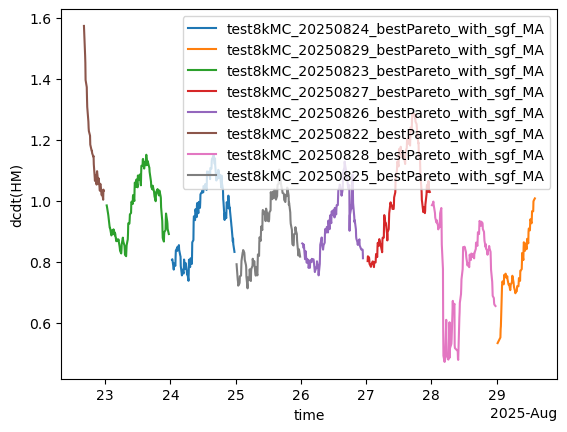

In [ ]:
fig, ax = plt.subplots()
for file in files:
    ds = xr.open_dataset(file)
    # print(ds)
    
    # ds['dcdt(HM)'].median(dim='MC').plot(label=file.stem, ax=ax)
    #moving average
    ds['dcdt(HM)'].rolling(time=5, center=True).mean().median(dim='MC').plot(label=file.stem+'_MA', ax=ax)

    # q16 = ds['dcdt(HM)'].quantile(0.16, dim='MC')
    # q84 = ds['dcdt(HM)'].quantile(0.84, dim='MC')
    # ax.fill_between(ds['time'], q16, q84, alpha=0.3)

    ax.legend()
    # break

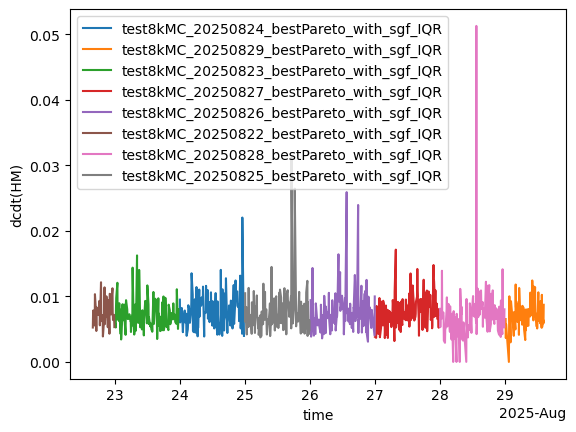

In [ ]:
fig, ax = plt.subplots()

for file in files:
    ds = xr.open_dataset(file)
    # print(ds)
    
    # ds['dcdt(HM)'].median(dim='MC').plot(label=file.stem, ax=ax)
    #moving average
    # ds['dcdt(HM)'].rolling(time=5, center=True).mean().median(dim='MC').plot(label=file.stem+'_MA', ax=ax)

    q16 = ds['dcdt(HM)'].quantile(0.16, dim='MC')
    q84 = ds['dcdt(HM)'].quantile(0.84, dim='MC')
    diff = q84 - q16
    diff.plot(label=file.stem+'_IQR', ax=ax)
    # ax.fill_between(ds['time'], q16, q84, alpha=0.3)

    ax.legend()
    # break